In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\aishw\Downloads\Interactive_KPI_Dashboard_Project
['Final_Analytical_Retail_KPI_Notebook.ipynb', 'Interactive_KPI_Dashboard']


In [5]:
import os

print(os.listdir("Interactive_KPI_Dashboard"))

['app.py', 'Dashboard', 'Data', 'PROJECT_STRUCTURE.txt', 'README.md', 'requirements.txt', 'run.bat']


In [6]:
import os

print(os.listdir("Interactive_KPI_Dashboard/Data"))

['clean_dataset.csv', 'clean_dataset.zip']


In [7]:
import pandas as pd

df = pd.read_csv("Interactive_KPI_Dashboard/Data/clean_dataset.csv")

df.head()

C:\Users\aishw\AppData\Local\Temp\ipykernel_21772\200981730.py:3: DtypeWarning: Columns (0: invoiceno) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Interactive_KPI_Dashboard/Data/clean_dataset.csv")


,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,is_return,year,month,month_name,total_sales,estimated_cost,estimated_profit,estimated_profit_margin
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,2010,12,December,15.30,10.710,4.590,30.0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,2010,12,December,20.34,14.238,6.102,30.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,2010,12,December,22.00,15.400,6.600,30.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,2010,12,December,20.34,14.238,6.102,30.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,2010,12,December,20.34,14.238,6.102,30.0


In [8]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (526021, 16)

Column Names:
['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country', 'is_return', 'year', 'month', 'month_name', 'total_sales', 'estimated_cost', 'estimated_profit', 'estimated_profit_margin']

Missing Values:
invoiceno                  0
stockcode                  0
description                0
quantity                   0
invoicedate                0
unitprice                  0
customerid                 0
country                    0
is_return                  0
year                       0
month                      0
month_name                 0
total_sales                0
estimated_cost             0
estimated_profit           0
estimated_profit_margin    0
dtype: int64


In [9]:
# KPI Calculations

total_revenue = df["total_sales"].sum()
total_orders = df["invoiceno"].nunique()
total_quantity = df["quantity"].sum()
total_customers = df.loc[df["customerid"] != 0, "customerid"].nunique()

average_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value, 2))
print("Total Customers:", total_customers)
print("Total Quantity Sold:", total_quantity)

Total Revenue: 7181282.41
Total Orders: 20730
Average Order Value: 346.42
Total Customers: 4339
Total Quantity Sold: 3643622


In [10]:
# Top 10 Products by Revenue

top_products = (
    df.groupby("description")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

description
REGENCY CAKESTAND 3 TIER              93034.80
PARTY BUNTING                         64157.76
WHITE HANGING HEART T-LIGHT HOLDER    60604.10
JUMBO BAG RED RETROSPOT               46417.86
PAPER CHAIN KIT 50'S CHRISTMAS        36210.04
ASSORTED COLOUR BIRD ORNAMENT         35690.25
SPOTTY BUNTING                        33314.05
CHILLI LIGHTS                         32126.28
JAM MAKING SET WITH JARS              30359.99
SET OF 3 CAKE TINS PANTRY DESIGN      28078.15
Name: total_sales, dtype: float64


In [11]:
# Top 10 Countries by Revenue

top_countries = (
    df.groupby("country")["total_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_countries)

country
United Kingdom    6173370.454
Germany            187834.430
EIRE               179751.510
France             162395.640
Netherlands         90528.750
Australia           47639.360
Switzerland         45047.560
Spain               42484.810
Belgium             36111.110
Norway              27253.560
Name: total_sales, dtype: float64


In [12]:
# Monthly Revenue Trend

df["invoicedate"] = pd.to_datetime(df["invoicedate"])

monthly_revenue = (
    df.groupby(df["invoicedate"].dt.to_period("M"))["total_sales"]
    .sum()
)

monthly_revenue.index = monthly_revenue.index.astype(str)

print(monthly_revenue)

invoicedate
2010-12     562395.620
2011-01     431308.590
2011-02     373327.690
2011-03     494463.540
2011-04     383757.361
2011-05     540598.020
2011-06     488060.150
2011-07     493249.241
2011-08     503099.260
2011-09     730367.332
2011-10     793852.830
2011-11    1062365.740
2011-12     324437.040
Name: total_sales, dtype: float64


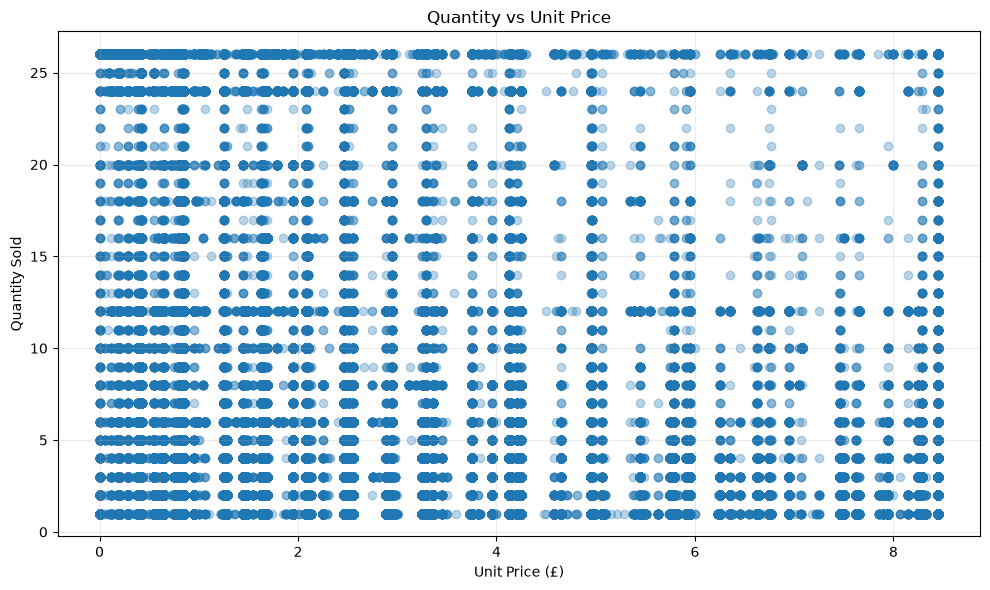

In [13]:
# Quantity vs Unit Price Analysis

plt.figure(figsize=(10, 6))

plt.scatter(
    df["unitprice"],
    df["quantity"],
    alpha=0.3
)

plt.title("Quantity vs Unit Price")
plt.xlabel("Unit Price (£)")
plt.ylabel("Quantity Sold")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [14]:
# Business Insights

print("===== BUSINESS INSIGHTS =====")

print("\n1. Revenue:")
print(f"Total Revenue = £{total_revenue:,.2f}")

print("\n2. Orders:")
print(f"Total Orders = {total_orders:,}")

print("\n3. Customers:")
print(f"Total Customers = {total_customers:,}")

print("\n4. Average Order Value:")
print(f"AOV = £{average_order_value:,.2f}")

print("\n5. Top Product:")
print(f"{top_products.index[0]}")

print("\n6. Top Country:")
print(f"{top_countries.index[0]}")

print("\n7. Quantity Sold:")
print(f"{total_quantity:,}")

===== BUSINESS INSIGHTS =====

1. Revenue:
Total Revenue = £7,181,282.41

2. Orders:
Total Orders = 20,730

3. Customers:
Total Customers = 4,339

4. Average Order Value:
AOV = £346.42

5. Top Product:
REGENCY CAKESTAND 3 TIER

6. Top Country:
United Kingdom

7. Quantity Sold:
3,643,622
